# Analyse Qualite de l'Air
## Projet IA1 - Datagreen

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
%matplotlib inline

In [3]:
df = pd.read_csv('../clean_data.csv', parse_dates=['timestamp_utc'])
print(f'{len(df)} lignes chargees')
print(f'{df["city_id"].nunique()} villes')

42539 lignes chargees
5 villes


In [4]:
stats = df.groupby('city_name')['aqi'].agg(['mean', 'min', 'max']).round(2)
stats.columns = ['AQI Moyen', 'AQI Min', 'AQI Max']
stats.sort_values('AQI Moyen', ascending=False)

,AQI Moyen,AQI Min,AQI Max
city_name,,,
Beijing,4.27,1,5
New Delhi,3.55,1,5
Paris,1.74,1,4
Nairobi,1.19,1,5
Antananarivo,1.14,1,3


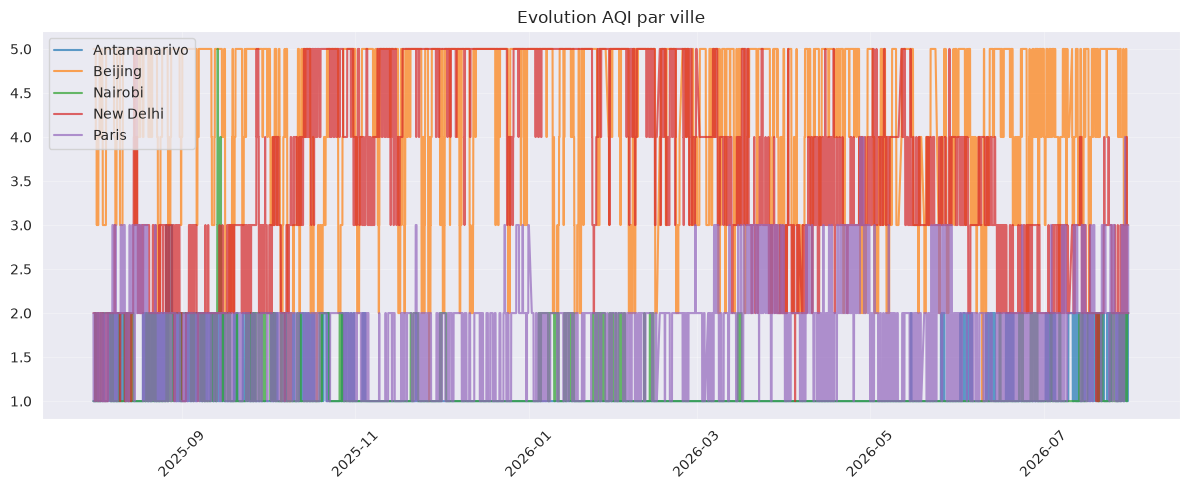

In [5]:
plt.figure(figsize=(12, 5))
for city in df['city_name'].unique():
    city_data = df[df['city_name'] == city]
    plt.plot(city_data['timestamp_utc'], city_data['aqi'], label=city, alpha=0.7)
plt.title('Evolution AQI par ville')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

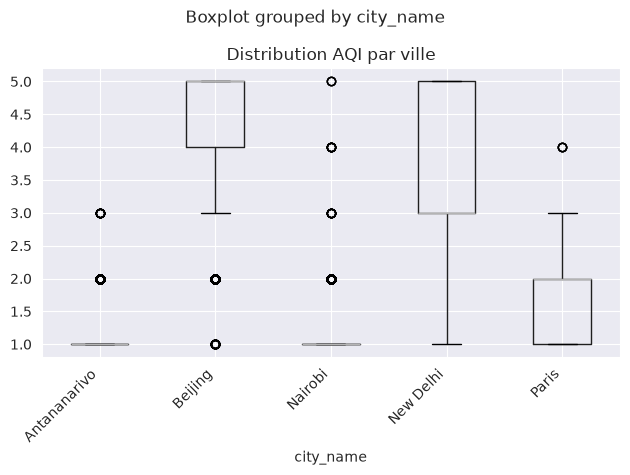

In [6]:
plt.figure(figsize=(10, 5))
df.boxplot(column='aqi', by='city_name')
plt.title('Distribution AQI par ville')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

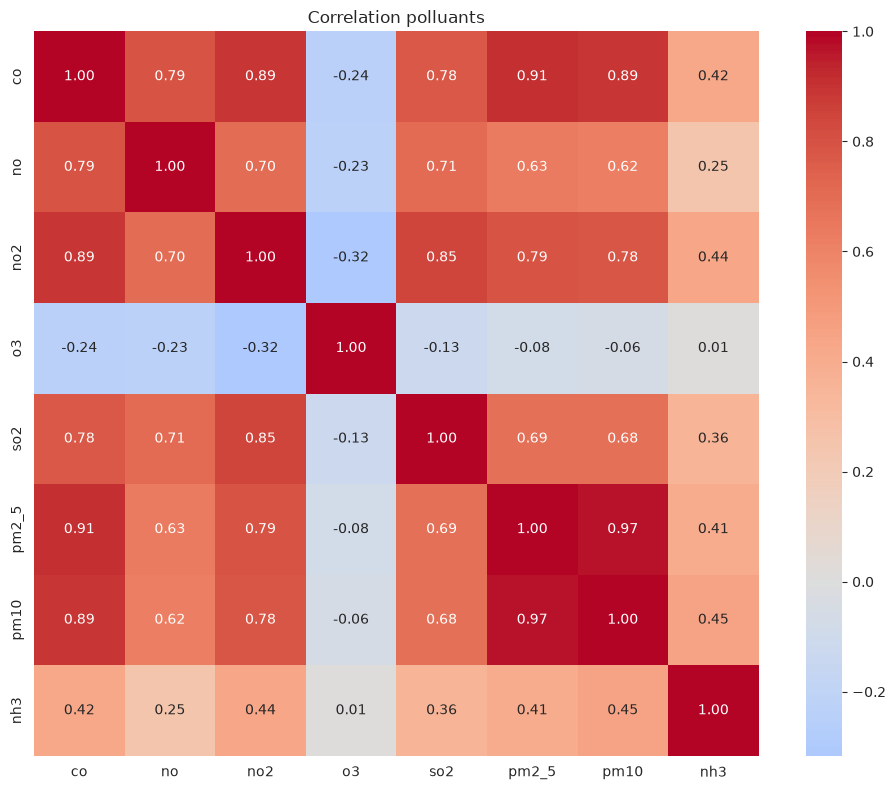

In [7]:
pollutants = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
corr = df[pollutants].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation polluants')
plt.tight_layout()
plt.show()

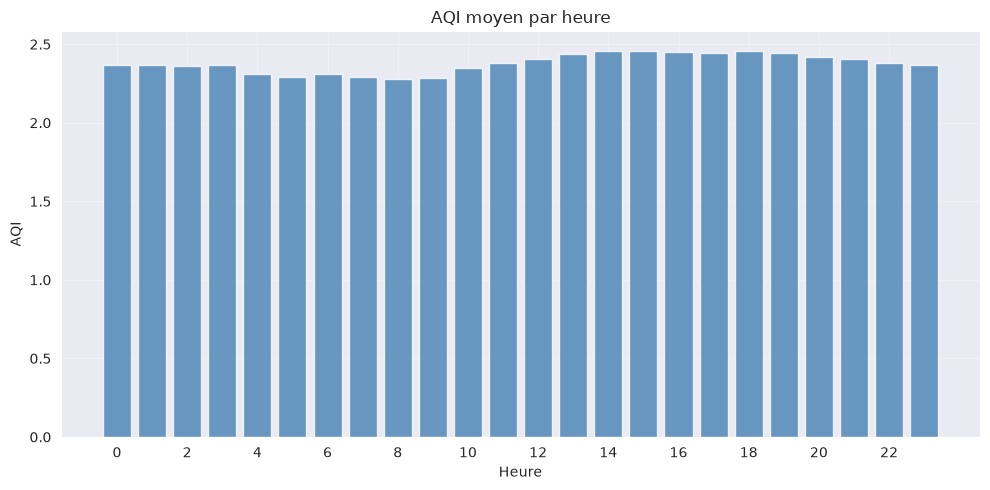

In [8]:
hourly = df.groupby(df['timestamp_utc'].dt.hour)['aqi'].mean()

plt.figure(figsize=(10, 5))
plt.bar(hourly.index, hourly.values, color='steelblue', alpha=0.8)
plt.title('AQI moyen par heure')
plt.xlabel('Heure')
plt.ylabel('AQI')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

In [9]:
print('='*50)
print('INSIGHTS')
print('='*50)

worst = df.groupby('city_name')['aqi'].mean().idxmax()
worst_val = df.groupby('city_name')['aqi'].mean().max()
best = df.groupby('city_name')['aqi'].mean().idxmin()
best_val = df.groupby('city_name')['aqi'].mean().min()
best_hour = df.groupby(df['timestamp_utc'].dt.hour)['aqi'].mean().idxmin()
worst_hour = df.groupby(df['timestamp_utc'].dt.hour)['aqi'].mean().idxmax()

print(f"Plus polluee: {worst} (AQI: {worst_val:.1f})")
print(f"Moins polluee: {best} (AQI: {best_val:.1f})")
print(f"Meilleure heure: {int(best_hour)}h")
print(f"Pire heure: {int(worst_hour)}h")

INSIGHTS
Plus polluee: Beijing (AQI: 4.3)
Moins polluee: Antananarivo (AQI: 1.1)
Meilleure heure: 8h
Pire heure: 15h


## Conclusion
- Beijing est la ville la plus polluee (AQI: 4.3)
- Antananarivo est la ville la moins polluee (AQI: 1.1)
- La meilleure qualite de l'air est a 8h
- La pire qualite de l'air est a 15h